In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
#loading the two datasets
train_df = pd.read_csv("X_train.csv")
delayed_col = pd.read_csv("y_train.csv")


In [4]:
full_df = train_df.copy()
full_df ["Delayed"] = delayed_col.iloc[:, 0] # merging both datasets
print(full_df.head(4))


   CARRIER_CODE  ORIGIN   DEST  ARR_TIME  ARR_DELAY  CARRIER_DELAY  \
0          12.0   299.0  273.0    1211.0       -4.0            0.0   
1          11.0   161.0   91.0    1244.0       -1.0            0.0   
2           2.0   266.0  247.0    2006.0       -5.0            0.0   
3           1.0    70.0  173.0    2218.0       -7.0            0.0   

   WEATHER_DELAY  NAS_DELAY  SECURITY_DELAY  LATE_AIRCRAFT_DELAY  DAY_OF_WEEK  \
0            0.0        0.0             0.0                  0.0            3   
1            0.0        0.0             0.0                  0.0            4   
2            0.0        0.0             0.0                  0.0            5   
3            0.0        0.0             0.0                  0.0            0   

   Delayed  
0        0  
1        0  
2        0  
3        0  


In [5]:
airline_delay_rate = full_df.groupby("CARRIER_CODE")["Delayed"].mean().sort_values()
airline_delay_rate

CARRIER_CODE
14.0    0.156139
0.0     0.171387
11.0    0.197163
10.0    0.202855
4.0     0.214595
8.0     0.226139
2.0     0.254801
12.0    0.258994
1.0     0.283064
13.0    0.309579
6.0     0.312817
7.0     0.322861
9.0     0.361732
3.0     0.373743
5.0     0.379956
Name: Delayed, dtype: float64

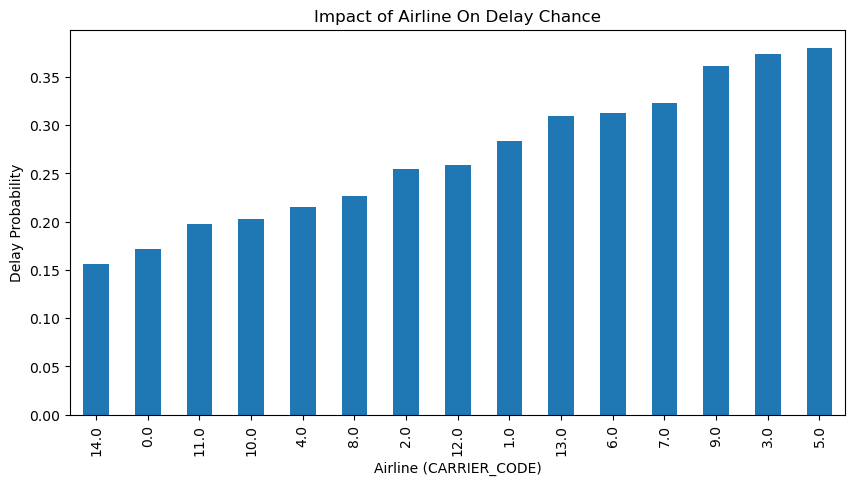

' \nBar chart \n\nx --> it is the CARRIER CODE (each bar represents an Airline)\n\ny --> it is the delay_probability (measures how often flightes are delayed) \n            --> if y = high then more delays, if y = low then less delays\n\n'

In [6]:
plt.figure(figsize=(10,5))
airline_delay_rate.plot(kind="bar")
plt.xlabel("Airline (CARRIER_CODE)")
plt.ylabel("Delay Probability")
plt.title("Impact of Airline On Delay Chance")
plt.show()

""" 
Bar chart 

x --> it is the CARRIER CODE (each bar represents an Airline)

y --> it is the delay_probability (measures how often flightes are delayed) 
            --> if y = high then more delays, if y = low then less delays

"""

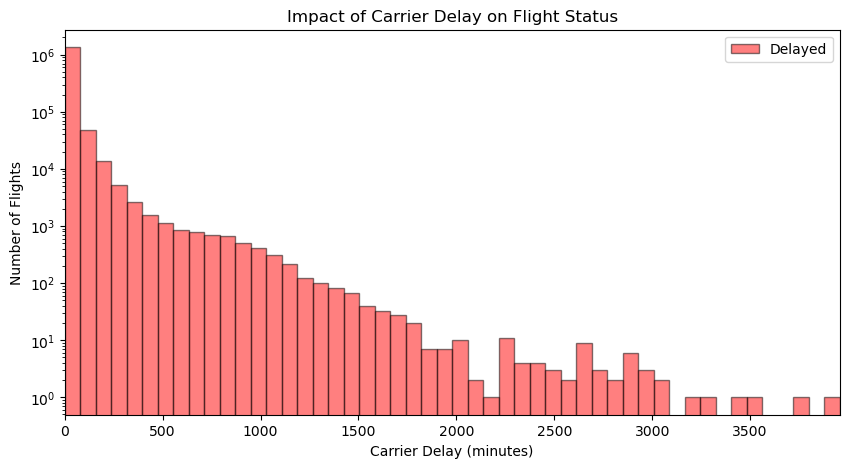

' \nX --> amount of delay caused by the airline itself\n        if X = low --> smaller carrier delay \n        if x = high --> bigger carrier delay\n\nY --> number of flights\n    number of flights per carrier \n    if Y = high --> many flights have that delay amount (minutes)\n    if Y = low --> few flights have that delay amount (minutes) \n\n'

In [7]:
plt.figure(figsize=(10, 5))
#histogram for delayed flights
plt.hist(full_df.loc[full_df["Delayed"]==1, "CARRIER_DELAY"], bins=50, alpha=0.5, label="Delayed", color="red", edgecolor="black")

plt.xlabel("Carrier Delay (minutes)")
plt.xlim(0, full_df["CARRIER_DELAY"].max())
plt.ylabel("Number of Flights")
plt.yscale("log") 
plt.title("Impact of Carrier Delay on Flight Status")
plt.legend()
plt.show()

""" 
X --> amount of delay caused by the airline itself
        if X = low --> smaller carrier delay 
        if x = high --> bigger carrier delay

Y --> number of flights
    number of flights per carrier 
    if Y = high --> many flights have that delay amount (minutes)
    if Y = low --> few flights have that delay amount (minutes) 

"""

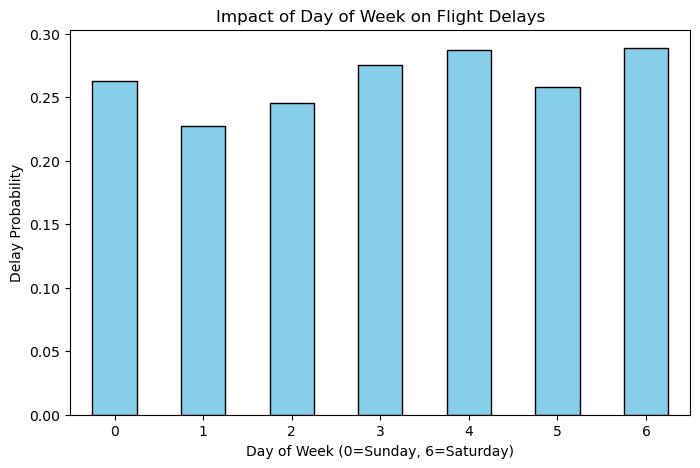

' \nX --> day of the week (0=Sunday, 6=Saturday) \nY --> Probablity that flight is delayed \n    if Y = high --> worse days, delays are most likey to occur\n    if Y = low --> good days, delays are less likely to occur\n\n'

In [8]:
#calculate delay probability for each day of the week
day_delay_rate = full_df.groupby("DAY_OF_WEEK")["Delayed"].mean()

plt.figure(figsize=(8,5))
day_delay_rate.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("Day of Week (0=Sunday, 6=Saturday)")
plt.ylabel("Delay Probability")
plt.title("Impact of Day of Week on Flight Delays")
plt.xticks(rotation=0)
plt.show()

""" 
X --> day of the week (0=Sunday, 6=Saturday) 
Y --> Probablity that flight is delayed 
    if Y = high --> worse days, delays are most likey to occur
    if Y = low --> good days, delays are less likely to occur

"""

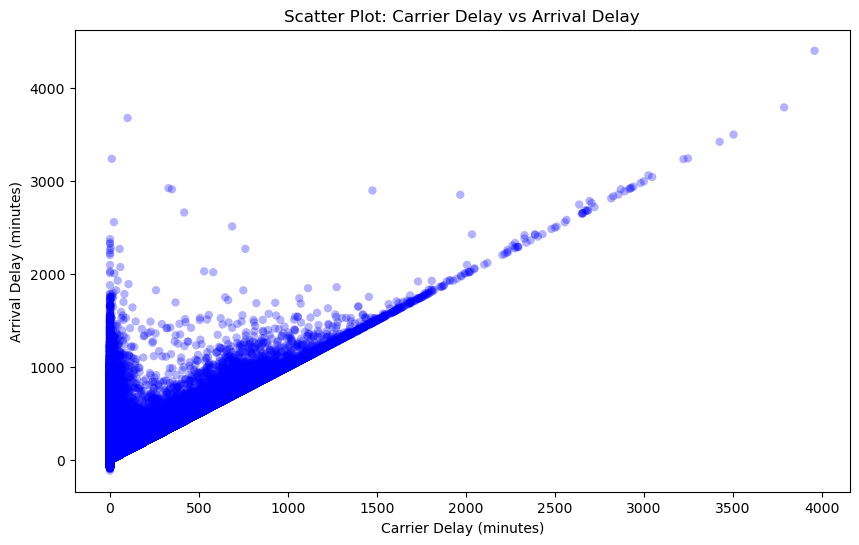

' \nX --> Carrier Delay \n        how many mins of delay were caused by the airline itself\n        if X = high --> the airine caused a high delay \n        if X = low --> the airline caused a low delay \n\nY --> Arrival Delay \n        by how many mins the flight actually arrived late \n        if Y = high --> the flight arrived on time (good)\n        if Y = low --> the flight arrived late (bad)\n\n'

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(full_df["CARRIER_DELAY"], full_df["ARR_DELAY"], alpha=0.3, color='blue', edgecolor='none')
plt.xlabel("Carrier Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Scatter Plot: Carrier Delay vs Arrival Delay")
plt.show()

""" 
X --> Carrier Delay 
        how many mins of delay were caused by the airline itself
        if X = high --> the airine caused a high delay 
        if X = low --> the airline caused a low delay 

Y --> Arrival Delay 
        by how many mins the flight actually arrived late 
        if Y = high --> the flight arrived on time (good)
        if Y = low --> the flight arrived late (bad)

"""

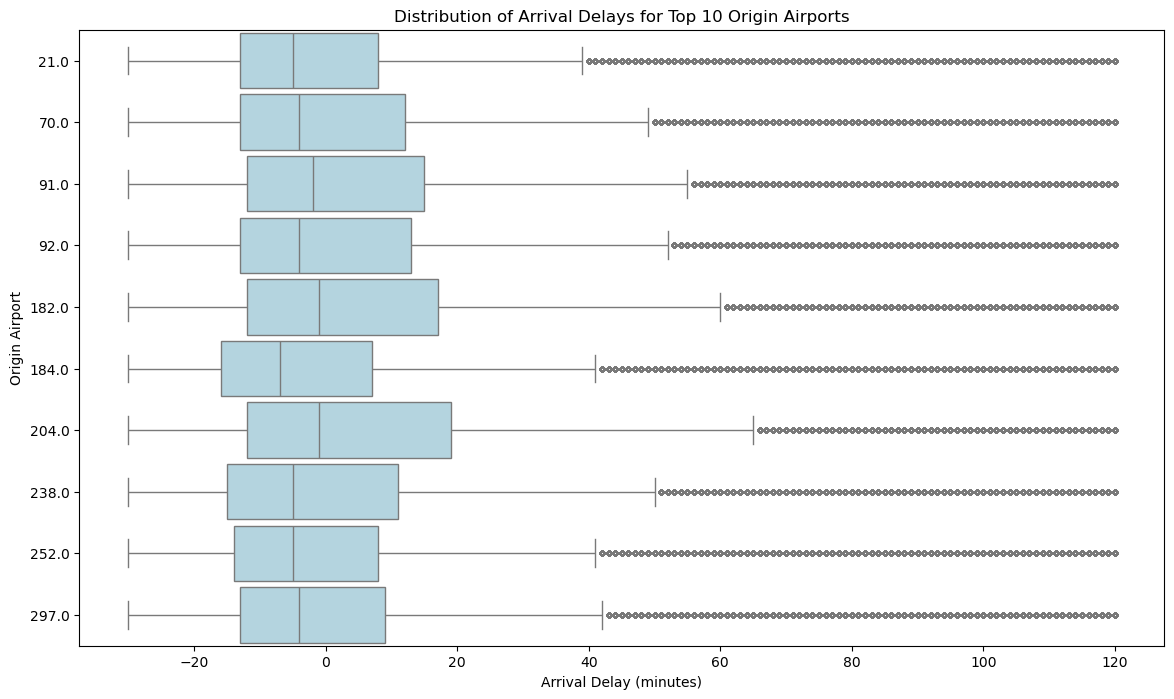

In [30]:
#top 10 busiest origin airports
top_airports = full_df["ORIGIN"].value_counts().head(10).index

df_top = full_df[full_df["ORIGIN"].isin(top_airports)].copy()

df_top["ARR_DELAY_CLIPPED"] = df_top["ARR_DELAY"].clip(lower=-30, upper=120)

plt.figure(figsize=(14,8))
sns.boxplot(x="ARR_DELAY_CLIPPED", y="ORIGIN", data=df_top, orient="h", width=0.9, fliersize=3, color="lightblue")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Origin Airport")
plt.title("Distribution of Arrival Delays for Top 10 Origin Airports")
plt.show()

""" 
For top 10 Busiest Airports 

    X --> Arrival Delays in minutes
        if X = high --> delays are happening 
        if X = low --> delays aren't happening 

    Y --> Origin (air port code) for the busiest airports
        each airport has its own box-plot 

"""

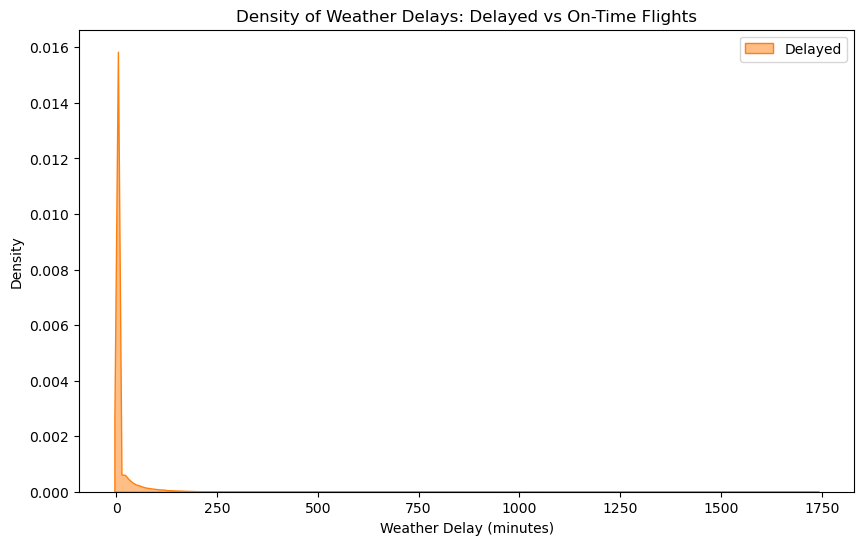

' \n    X --> delay in minutes caused specifically by weather\n        how long a flight was delayed due to weather \n\n        if X = high --> big weather delay\n        if X = low --> small weather delay\n\n    Y --> Probability (Density) of delays occuring at a given value\n\n        if Y = high --> more flights have experienced that delay in range\n        if Y = low --> less flights have experiences that delay in range\n\n'

In [12]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=full_df[full_df["Delayed"]==0],
    x="WEATHER_DELAY",
    fill=True,
    warn_singular=False,
    label="On Time",
    alpha=0.5
)
sns.kdeplot(
    data=full_df[full_df["Delayed"]==1],
    x="WEATHER_DELAY", 
    fill=True,
    warn_singular=False,
    label="Delayed",
    alpha=0.5
)

plt.xlabel("Weather Delay (minutes)")
plt.ylabel("Density")
plt.title("Density of Weather Delays: Delayed vs On-Time Flights")

ax = plt.gca()

plt.legend()
plt.show()

""" 
    X --> delay in minutes caused specifically by weather
        how long a flight was delayed due to weather 

        if X = high --> big weather delay
        if X = low --> small weather delay

    Y --> Probability (Density) of delays occuring at a given value

        if Y = high --> more flights have experienced that delay in range
        if Y = low --> less flights have experiences that delay in range

"""